# 🟠 VLM Rutilahu — Baseline Qwen2.5-VL-3B-Instruct
Zero-shot evaluation untuk keperluan model selection.

> Output file: `baseline_results.json` — digunakan di notebook comparison.

## ⚙️ Step 0 — Install

In [1]:
!pip install -q "transformers>=4.49.0" accelerate qwen-vl-utils pillow scikit-learn pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 MB 14.8 MB/s eta 0:00:00


## 📁 Step 1 — Upload Data

In [17]:
import os, json, re, torch
import pandas as pd
from google.colab import files
from PIL import Image
import zipfile

print('Upload cleaned_annotations.json:')
uploaded = files.upload()
with open(list(uploaded.keys())[0], 'r') as f:
    cleaned = json.load(f)
print(f'Dataset: {len(cleaned)} entri')

Upload cleaned_annotations.json:


Saving dataset.json to dataset (1).json
Dataset: 103 entri


In [3]:
print('Upload folder foto (.zip):')
uploaded_zip = files.upload()
IMAGE_DIR = '/content/images'
os.makedirs(IMAGE_DIR, exist_ok=True)
with zipfile.ZipFile(list(uploaded_zip.keys())[0], 'r') as z:
    z.extractall(IMAGE_DIR)

all_images = []
for root, dirs, fnames in os.walk(IMAGE_DIR):
    for f in fnames:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_images.append(os.path.join(root, f))
IMAGE_MAP = {os.path.basename(p): p for p in all_images}
print(f'{len(IMAGE_MAP)} foto ditemukan')

Upload folder foto (.zip):


Saving dataset_img.zip to dataset_img.zip
103 foto ditemukan


## 🤖 Step 2 — Load Model

In [4]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info

print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

MODEL_NAME = 'Qwen/Qwen2.5-VL-3B-Instruct'
print(f'\n⏳ Loading {MODEL_NAME}...')

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_NAME, torch_dtype=torch.float16, device_map='auto'
)
processor = AutoProcessor.from_pretrained(MODEL_NAME)
print('Model berhasil di-load!')
print(f'VRAM used: {torch.cuda.memory_allocated()/1e9:.1f} GB')

GPU: Tesla T4
VRAM: 15.6 GB

⏳ Loading Qwen/Qwen2.5-VL-3B-Instruct...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Model berhasil di-load!
VRAM used: 7.5 GB


## 🔍 Step 3 — Inference

In [22]:
SYSTEM_PROMPT = """Kamu adalah sistem AI untuk analisis kondisi Rumah Tidak Layak Huni (Rutilahu).\nAnalisis foto rumah dan berikan penilaian kondisi bangunan.\n\nLabel yang valid (gunakan PERSIS seperti di bawah):\n- roof_condition  : good | minor_damage | major_damage | collapsed\n- wall_condition  : good | minor_damage | major_damage | collapsed\n- wall_material   : concrete | brick | wood | bamboo | mixed | unknown\n- floor_condition : ceramic | cement | wood | dirt | unknown\n- severity_score  : 1 (Layak) | 2 (Perbaikan ringan) | 3 (Perbaikan sedang) | 4 (Tidak layak)\n\nJawab HANYA dalam format JSON valid. Jangan tambahkan teks apapun di luar JSON."""
USER_PROMPT   = """Analisis kondisi rumah ini. Jawab dalam format JSON:\n{\n  \"roof_condition\": \"good|minor_damage|major_damage|collapsed\",\n  \"wall_condition\": \"good|minor_damage|major_damage|collapsed\",\n  \"wall_material\": \"concrete|brick|wood|bamboo|mixed|unknown\",\n  \"floor_condition\": \"ceramic|cement|wood|dirt|unknown\",\n  \"severity_score\": (1-4),\n  \"explanation\": \"Penjelasan singkat dalam Bahasa Indonesia.\"\n}"""

VALID_LABELS = {
    "roof_condition"  : ["good", "minor_damage", "major_damage", "collapsed"],
    "wall_condition"  : ["good", "minor_damage", "major_damage", "collapsed"],
    "wall_material"   : ["concrete", "brick", "wood", "bamboo", "mixed", "unknown"],
    "floor_condition" : ["ceramic", "cement", "wood", "dirt", "unknown"],
}

def parse_json_output(text):
    try:
        match = re.search(r'\{.*\}', text, re.DOTALL)
        if match:
            parsed = json.loads(match.group())
            for k in VALID_LABELS:
                if k in parsed and isinstance(parsed[k], str):
                    parsed[k] = parsed[k].lower().strip()
            return parsed
        return {'error': 'no_json_found', 'raw_output': text[:200]}
    except Exception as e:
        return {'error': f'json_parse_error: {str(e)[:80]}'}

def build_result_entry(entry, pred):
    return {
        'image'             : entry['image'],
        'gt_roof'           : entry.get('roof_condition'),
        'gt_wall'           : entry.get('wall_condition'),
        'gt_wall_material'  : entry.get('wall_material'),
        'gt_floor'          : entry.get('floor_condition'),
        'gt_severity'       : int(entry.get('severity_score', 0)),
        'pred_roof'         : pred.get('roof_condition'),
        'pred_wall'         : pred.get('wall_condition'),
        'pred_wall_material': pred.get('wall_material'),
        'pred_floor'        : pred.get('floor_condition'),
        'pred_severity'     : pred.get('severity_score'),
        'explanation'       : pred.get('explanation', ''),
        'error'             : pred.get('error'),
    }

print('✅ Helper functions siap')

def run_inference(image_name):
    try:
        path = IMAGE_MAP.get(image_name)
        if not path:
            return {'error': f'file_not_found: {image_name}'}

        messages = [
            {'role': 'system', 'content': SYSTEM_PROMPT},
            {'role': 'user', 'content': [
                {'type': 'image', 'image': f'file://{path}'},
                {'type': 'text',  'text': USER_PROMPT}
            ]}
        ]
        text = processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        image_inputs, video_inputs = process_vision_info(messages)
        inputs = processor(
            text=[text], images=image_inputs, videos=video_inputs,
            padding=True, return_tensors='pt'
        ).to(model.device)

        with torch.no_grad():
            generated_ids = model.generate(
                **inputs, max_new_tokens=512,
                do_sample=False, temperature=None, top_p=None
            )
        trimmed = [out[len(inp):] for inp, out in zip(inputs.input_ids, generated_ids)]
        output_text = processor.batch_decode(
            trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
        )[0]
        return parse_json_output(output_text)

    except Exception as e:
        torch.cuda.empty_cache()
        return {'error': str(e)[:100]}

print('✅ Fungsi inference siap')

✅ Helper functions siap
✅ Fungsi inference siap


In [25]:
from tqdm import tqdm

results = []
print(f'Qwen2.5-VL-3B inference pada {len(cleaned)} foto...\n')

for i, entry in enumerate(tqdm(cleaned, desc='Qwen2.5-VL')):
    pred = run_inference(entry['image'])
    results.append(build_result_entry(entry, pred))
    if (i + 1) % 10 == 0:
        errors = sum(1 for r in results if r['error'])
        print(f'  [{i+1}/{len(cleaned)}] Error: {errors}')

with open('/content/baseline_results.json', 'w') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)
print(f'\nSelesai! Error total: {sum(1 for r in results if r["error"])}')

Qwen2.5-VL-3B inference pada 103 foto...



Qwen2.5-VL:  10%|▉         | 10/103 [03:33<18:03, 11.65s/it]

  [10/103] Error: 3


Qwen2.5-VL:  19%|█▉        | 20/103 [04:57<11:50,  8.56s/it]

  [20/103] Error: 3


...

  [90/103] Error: 7


Qwen2.5-VL:  97%|█████████▋| 100/103 [18:03<00:25,  8.64s/it]

  [100/103] Error: 9


Qwen2.5-VL: 100%|██████████| 103/103 [18:29<00:00, 10.77s/it]


Selesai! Error total: 9


## 📊 Step 4 — Evaluasi

In [34]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.DataFrame(results)
df_valid = df[df['error'].isna()].copy()
df_valid['pred_severity'] = pd.to_numeric(df_valid['pred_severity'], errors='coerce')
df_valid = df_valid.dropna(subset=['pred_severity'])
df_valid['pred_severity'] = df_valid['pred_severity'].astype(int)

print(f'Total: {len(df)} | Berhasil: {len(df_valid)} | Error: {df["error"].notna().sum()}')

exact = accuracy_score(df_valid['gt_severity'], df_valid['pred_severity'])
tol   = (abs(df_valid['gt_severity'] - df_valid['pred_severity']) <= 1).mean()
print(f'\nExact Accuracy  : {exact:.2%}')
print(f'Tolerance ±1    : {tol:.2%}')
print('\nClassification Report Severity:')
print(classification_report(
    df_valid['gt_severity'], df_valid['pred_severity'],
    labels=[1,2,3,4],
    target_names=['Layak(1)','Perbaikan Ringan(2)','Perbaikan Sedang(3)','Tidak Layak(4)'],
    zero_division=0
))
print('Akurasi per Komponen:')
for col, label in [('roof','Atap'),('wall','Dinding'),('wall_material','Material Dinding'),('floor','Lantai')]:
    d = df_valid[[f'gt_{col}',f'pred_{col}']].dropna()
    if len(d) > 0:
        print(f'  {label:20s}: {accuracy_score(d[f"gt_{col}"], d[f"pred_{col}"]):.2%}')

Total: 103 | Berhasil: 94 | Error: 9

Exact Accuracy  : 47.87%
Tolerance ±1    : 89.36%

Classification Report Severity:
                     precision    recall  f1-score   support

           Layak(1)       0.84      0.50      0.63        32
Perbaikan Ringan(2)       0.30      0.47      0.37        15
Perbaikan Sedang(3)       0.40      0.74      0.52        23
     Tidak Layak(4)       0.56      0.26      0.36        19

          micro avg       0.48      0.51      0.49        89
          macro avg       0.52      0.49      0.47        89
       weighted avg       0.57      0.51      0.50        89

Akurasi per Komponen:
  Atap                : 51.06%
  Dinding             : 42.55%
  Material Dinding    : 24.73%
  Lantai              : 38.30%


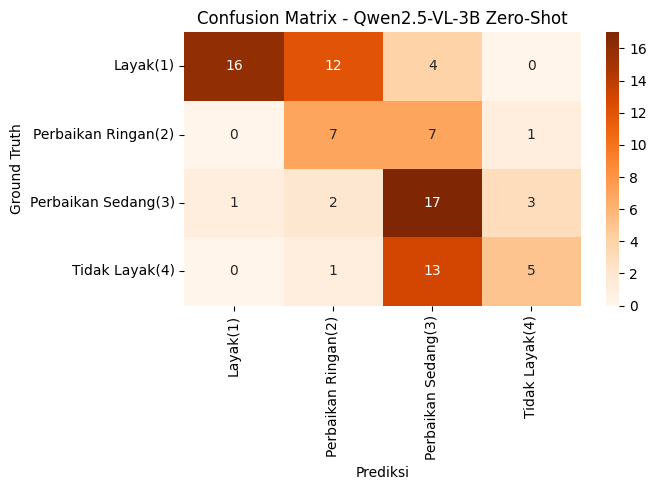

In [33]:
fig, ax = plt.subplots(figsize=(7,5))
cm = confusion_matrix(df_valid['gt_severity'], df_valid['pred_severity'], labels=[1,2,3,4])
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax,
    xticklabels=['Layak(1)','Perbaikan Ringan(2)','Perbaikan Sedang(3)','Tidak Layak(4)'],
    yticklabels=['Layak(1)','Perbaikan Ringan(2)','Perbaikan Sedang(3)','Tidak Layak(4)'])
ax.set_xlabel('Prediksi'); ax.set_ylabel('Ground Truth')
ax.set_title('Confusion Matrix - Qwen2.5-VL-3B Zero-Shot')
plt.tight_layout()
plt.savefig('/content/qwen_confusion_matrix.png', dpi=150)
plt.show()

In [28]:
files.download('/content/baseline_results.json')
files.download('/content/qwen_confusion_matrix.png')
print('Download selesai')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download selesai
